# 지도학습 - 회귀 둘러보기
여러 개의 Feature를 가지고 연속 된 target 하나를 예측하는 것을 회귀(Regression) 예측이라 한다.

## 최근접 이웃 회귀 모델

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
# 농어의 길이가 입력(특성)이고 무게가 라벨(타겟)이 된다.
perch_length = np.array([
    8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
    21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
    22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
    27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
    36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
    40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([
    5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
    110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
    130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
    197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
    514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
    820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
    1000.0, 1000.0])

print(perch_length.shape, perch_weight.shape)

(56,) (56,)


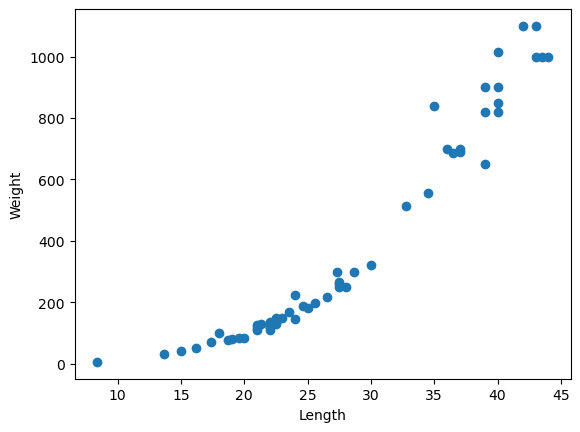

In [3]:
# 두 연속형 데이터를 산포도 시각화
plt.scatter(perch_length, perch_weight)
plt.xlabel('Length')
plt.ylabel('Weight')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# 입력 데이터 2차원으로 변경
perch_length = perch_length.reshape(-1,1)

# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    perch_length,
    perch_weight,
    random_state = 0
)

# stratify : 타겟 데이터의 비율에 맞춰 split 속성은 필요 X

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(42, 1) (42,)
(14, 1) (14,)


In [5]:
# 모델 학습
from sklearn.neighbors import KNeighborsRegressor

# 주어진 데이터와 가장 가까운 이웃 n개를 찾고, 이웃의 평균 값 예측
kn_reg = KNeighborsRegressor()
kn_reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 결정 계수 ($R^2$)

$$
R^2 = 1 − \frac{\sum\limits_{i=1}^{n}(y_i−\hat{y_i})^2}{\sum\limits_{i=1}^{n}(y_i−\bar{y_i})^2}
$$

* $y_i$는 실제 값이다.

* $\hat{y}_i$는 모델이 예측한 값이다.

* $\bar{y}$는 실제 값의 평균이다.

* $\sum\limits_{i=1}^{n}(y_i−\hat{y_i})^2$는 **잔차 제곱합(Sum of Squares of Residuals, SSR)** 이라 하며, 모델이 예측한 값과 실제 값 사이의 차이를 나타낸다.

* $\sum\limits_{i=1}^{n}(y_i−\bar{y_i})^2$는 **총 변동합(Total Sum of Squares, SST)** 이라 하며, 실제 값의 평균에 대한 변동성을 나타낸다.

---

### $R^2$의 특징

* **범위**: $R^2$ 값은 일반적으로 0에서 1 사이의 값을 가지며, 1에 가까울수록 모델이 데이터를 잘 설명한다는 것을 의미한다. 그러나 일부 모델에서는 음수 값을 가질 수도 있다.

* **높은 $R^2$ 값의 의미**: 높은 $R^2$ 값은 회귀 모델이 독립 변수들을 사용하여 종속 변수의 변동을 잘 설명하고 있다는 것을 나타낸다. 이는 모델이 좋은 피팅을 제공하고 있다는 것을 의미한다.

* **낮은 $R^2$ 값의 의미**: 낮은 $R^2$ 값은 모델이 데이터를 잘 설명하지 못하고 있다는 것을 의미한다. 이는 모델이 중요한 패턴이나 변수들을 놓치고 있다는 것을 시사한다.

In [6]:
# 회귀 평가(결정 계수: 1에 가까울수록 좋은 예측)
print(kn_reg.score(X_train, y_train))
print(kn_reg.score(X_test, y_test))

0.9831253192289525
0.9162089041423581


In [7]:
# 모델 예측
y_pred = kn_reg.predict(X_test[:1])
y_pred

array([897.])

In [8]:
# 이웃 조회
_, index = kn_reg.kneighbors(X_test[:1])
index

array([[41,  1, 40, 17,  7]])

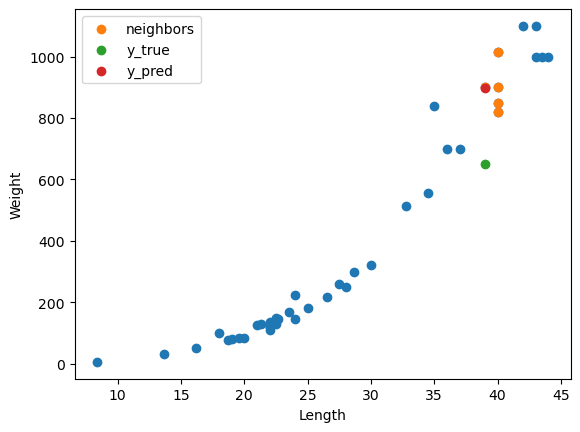

In [9]:
# 시각화
plt.scatter(X_train, y_train)
plt.scatter(X_train[index[0]], y_train[index[0]], label='neighbors')
plt.scatter(X_test[0], y_test[0], label='y_true')
plt.scatter(X_test[0], y_pred, label='y_pred')

plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.show()

## 최근접이웃모델의 한계
 - 범위를 벗어난 예측이 불가능하다.
 - 데이터의 전체적인 경향을 학습하지 못한다.
 - 국소적인 정보에만 의존한다.

In [12]:
kn_leg = KNeighborsRegressor()
kn_leg.fit(X_train, y_train)
y_pred = kn_reg.predict([[50],[70],[300]])
y_pred

array([1040., 1040., 1040.])

In [22]:
# 이웃 조회
x = 50 # 70 or 100
_, index = kn_reg.kneighbors([[x]])
y_pred = kn_leg.predict([[x]])

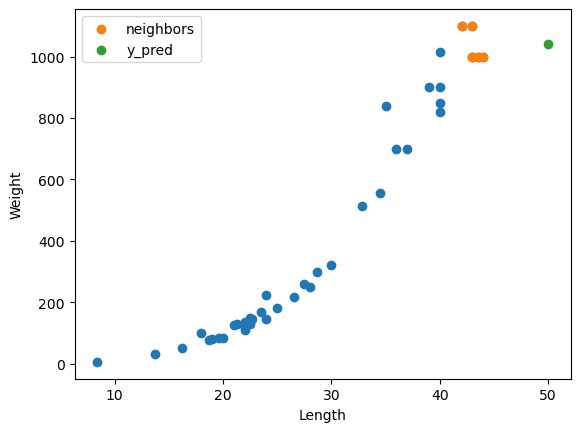

In [23]:
# 시각화
plt.scatter(X_train, y_train)
plt.scatter(X_train[index[0]], y_train[index[0]], label='neighbors')
plt.scatter(x, y_pred, label='y_pred')

plt.xlabel('Length')
plt.ylabel('Weight')
plt.legend()
plt.show()

## 선형 회귀

**`sklearn.linear_model.LinearRegression`**

1. **`coef_` (회귀 계수)**:
   - `coef_`는 학습된 선형 회귀 모델의 각 특성(feature)에 대한 가중치(weight) 또는 회귀 계수(coefficient)이다.
   - 선형 회귀 모델의 방정식은 다음과 같은 형태로 표현된다:

   $$
   y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
   $$

   여기서 $w_1, w_2, \dots, w_n$이 각각의 특성에 대한 회귀 계수이고, 이 값이 바로 `coef_`에 해당한다. 즉, `coef_`는 특성 $x$에 대한 선형 관계에서 기울기를 나타낸다.

   - `coef_`의 크기와 부호는 각 특성이 종속 변수 $y$에 미치는 영향을 나타낸다:
     - **양수**이면, 해당 특성 값이 증가할 때 $y$도 증가한다.
     - **음수**이면, 해당 특성 값이 증가할 때 $y$는 감소한다.
     - **0**이면, 해당 특성은 $y$에 영향을 미치지 않는다.

2. **`intercept_` (절편)**:
   - `intercept_`는 회귀 직선이 y축을 교차하는 점을 의미하는 절편 값이다.
   - 선형 회귀 방정식에서 절편 $b$에 해당하는 값으로, 독립 변수 $x_1, x_2, \dots, x_n$가 모두 0일 때 종속 변수 $y$의 예측 값이다.

   $$
   y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
   $$

In [24]:
from sklearn.linear_model import LinearRegression

# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# 예측
y_pred = lin_reg.predict([[50],[70],[100]])
y_pred

array([1228.52162131, 1983.85136016, 3116.84596844])

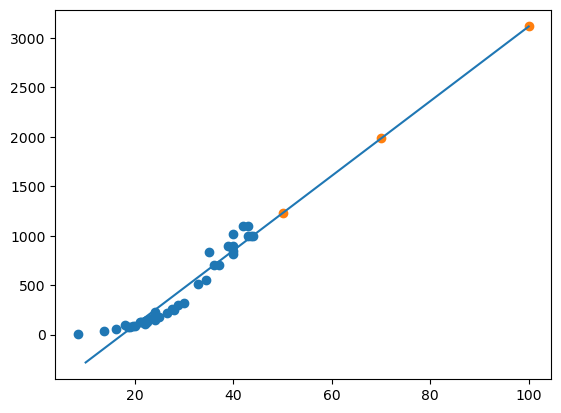

In [28]:
# 시각화
plt.scatter(X_train, y_train)
plt.scatter([[50],[70],[100]], y_pred)

plt.plot([10,100], [lin_reg.predict([[10]]), lin_reg.predict([[100]])])
plt.show()

In [30]:
# 학습 된 회귀계수, 절편
# 회귀 계수는 특성마다 만들어짐 y = WX + b (w1 * x + w2 * x + ...)
print('w : ', lin_reg.coef_)
print('b : ', lin_reg.intercept_)

pred = lin_reg.coef_ * [[50],[70],[100]] + lin_reg.intercept_
pred

w :  [37.76648694]
b :  -659.8027258214022


array([[1228.52162131],
       [1983.85136016],
       [3116.84596844]])

# 3개의 feature로 무게 예측

In [31]:
perch_df = pd.read_csv('data/perch_full.csv')
perch_df.head()

,length,height,width,weight
0,8.4,2.11,1.41,5.9
1,13.7,3.53,2.00,32.0
2,15.0,3.82,2.43,40.0
3,16.2,4.59,2.63,51.5
4,17.4,4.59,2.94,70.0


In [32]:
# 입력/라벨 분리
X = perch_df[['length','height','width']].to_numpy()
y = perch_df['weight'].to_numpy()

# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(42, 3) (42,)
(14, 3) (14,)


In [33]:
# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
# 모델 평가
print(lin_reg.score(X_train, y_train))
print(lin_reg.score(X_test, y_test))

0.9465527597362248
0.8976637619464427


In [39]:
# 회귀 계수 절편 확인
print(lin_reg.coef_, lin_reg.intercept_)

X = X_test[0]
W = lin_reg.coef_
b = lin_reg.intercept_

print((X[0]*W[0] + X[1]*W[1] + X[2]*W[2]) + b)
print(X @ W + b)
print(lin_reg.predict(X_test[:1]))

[-6.27867158e-02  8.47087745e+01  5.98738610e+01] -556.5487530502903
743.9014788818606
743.9014788818606
[743.90147888]


## 특성 공학 (Feature Engineering)

특성공학이란?
모델이 데이터를 더 잘 이해할 수 있도록 입력 데이터를 가공하고 변환하는 과정이다.
예시: 길이만 사용하는 것보다 길이²나 길이×높이를 추가하면 패턴을 더 잘 학습할 수 있다.

1. 특성 생성
- 새로운 변수 도출  
  기존 데이터를 조합하여 의미 있는 새로운 변수를 만든다.  
  예시: 키와 몸무게로 BMI 생성

- 다항특성생성  
  기존 변수의 제곱, 세제곱 등을 추가하여 비선형 관계를 표현한다.  
  예시: 길이 → 길이² 추가

- 상호작용특성  
  두 변수의 곱을 통해 변수 간 관계를 반영한다.  
  예시: 길이 × 높이 → 부피와 유사한 의미 생성

2. 특성 변환
- 스케일링  
  변수들의 범위를 맞춰 모델이 공정하게 학습하도록 한다.  
  예시: 길이(10~100)와 무게(100~1000)를 0~1 범위로 변환

- 로그변환  
  값의 분포가 한쪽으로 치우친 경우 이를 완화한다.  
  예시: 매출 데이터에 log 적용하여 큰 값 영향 줄이기

- 이산화  
  연속형 데이터를 구간으로 나누어 범주형으로 변환한다.  
  예시: 나이 → 10대, 20대, 30대

3. 차원 축소
- 주성분 분석  
  여러 변수를 몇 개의 핵심 변수로 압축한다.  
  예시: 10개 변수 → 2~3개로 축소

- 선택적 특성 제거  
  중요하지 않은 변수를 제거하여 모델을 단순화한다.  
  예시: 영향 없는 컬럼 제거

4. 결측치 처리
- 결측값 대체  
  비어있는 값을 적절한 값으로 채운다.  
  예시: 나이 결측값 → 평균값으로 대체

5. 범주형 변수 처리
- 더미인코딩  
  범주형 데이터를 0과 1로 변환한다.  
  예시: 성별 → 남자(1,0), 여자(0,1)

- 라벨인코딩  
  범주를 숫자로 매핑한다.  
  예시: 등급 → A=0, B=1, C=2

6. 도메인 지식 활용
문제 영역에 대한 지식을 활용하여 의미 있는 특성을 만든다.  
예시: 생선 데이터에서 길이, 높이, 너비를 조합해 부피 개념 생성

# 다항 처리

In [ ]:
# 다항식 추가 클래스
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2) # 기본 값 degree = 2
X = [[2,3]] # 2개의 특성
X_poly = poly.fit_transform(X)
print(X_poly)
print(poly.get_feature_names_out())
# bias 값 1, 기존 특성 값 2개, 서로를 곱한 값 1개, 각각 제곱한 값 2개 => 6개

[[1. 2. 3. 4. 6. 9.]]
['1' 'x0' 'x1' 'x0^2' 'x0 x1' 'x1^2']


In [ ]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X = [[2,3],[3,4]]
X_poly = poly.fit_transform(X)
print(X_poly)
print(poly.get_feature_names_out())


[[ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]
 [ 1.  3.  4.  9. 12. 16. 27. 36. 48. 64.]]
['1' 'x0' 'x1' 'x0^2' 'x0 x1' 'x1^2' 'x0^3' 'x0^2 x1' 'x0 x1^2' 'x1^3']


In [44]:
# 농어 데이터에 2차 다항식 적용
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3개의 특성을 2차 다항식을 적용하여 9개의 특성으로 변경
print(X_train.shape, X_train_poly.shape)
print(X_test.shape, X_test_poly.shape)

pd.DataFrame(X_train_poly, columns=poly.get_feature_names_out()).head()

(42, 3) (42, 9)
(14, 3) (14, 9)


,x0,x1,x2,x0^2,x0 x1,x0 x2,x1^2,x1 x2,x2^2
0,27.5,7.17,4.34,756.25,197.175,119.350,51.4089,31.1178,18.8356
1,40.0,12.38,7.46,1600.00,495.200,298.400,153.2644,92.3548,55.6516
2,32.8,10.03,6.02,1075.84,328.984,197.456,100.6009,60.3806,36.2404
3,19.0,5.64,3.05,361.00,107.160,57.950,31.8096,17.2020,9.3025
4,22.0,6.11,3.41,484.00,134.420,75.020,37.3321,20.8351,11.6281


In [45]:
# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

# 학습 된 회귀 계수, 절편
print(lin_reg.coef_)
print(lin_reg.intercept_)

[ -9.20841871 -70.08898739  53.34928013   1.86684753  -7.57020239
  -4.44223465  37.19721377 -53.29722987  53.81195523]
118.29701722530785


In [46]:
# 모델 평가
print(lin_reg.score(X_train_poly, y_train))
print(lin_reg.score(X_test_poly, y_test))

0.9930481471109651
0.9515369884407662


In [47]:
# 농어 데이터에 3차 다항식 적용
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3개의 특성을 2차 다항식을 적용하여 9개의 특성으로 변경
print(X_train.shape, X_train_poly.shape)
print(X_test.shape, X_test_poly.shape)

pd.DataFrame(X_train_poly, columns=poly.get_feature_names_out()).head()

(42, 3) (42, 19)
(14, 3) (14, 19)


,x0,x1,x2,x0^2,x0 x1,x0 x2,x1^2,x1 x2,x2^2,x0^3,x0^2 x1,x0^2 x2,x0 x1^2,x0 x1 x2,x0 x2^2,x1^3,x1^2 x2,x1 x2^2,x2^3
0,27.5,7.17,4.34,756.25,197.175,119.350,51.4089,31.1178,18.8356,20796.875,5422.3125,3282.1250,1413.74475,855.73950,517.97900,368.601813,223.114626,135.051252,81.746504
1,40.0,12.38,7.46,1600.00,495.200,298.400,153.2644,92.3548,55.6516,64000.000,19808.0000,11936.0000,6130.57600,3694.19200,2226.06400,1897.413272,1143.352424,688.966808,415.160936
2,32.8,10.03,6.02,1075.84,328.984,197.456,100.6009,60.3806,36.2404,35287.552,10790.6752,6476.5568,3299.70952,1980.48368,1188.68512,1009.027027,605.617418,363.491212,218.167208
3,19.0,5.64,3.05,361.00,107.160,57.950,31.8096,17.2020,9.3025,6859.000,2036.0400,1101.0500,604.38240,326.83800,176.74750,179.406144,97.019280,52.466100,28.372625
4,22.0,6.11,3.41,484.00,134.420,75.020,37.3321,20.8351,11.6281,10648.000,2957.2400,1650.4400,821.30620,458.37220,255.81820,228.099131,127.302461,71.047691,39.651821


In [48]:
# 모델 학습
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

# 학습 된 회귀 계수, 절편
print(lin_reg.coef_)
print(lin_reg.intercept_)

[   57.2749514     65.56010744  -537.18266364   -47.83305755
   246.6144203    133.04789167   -85.45052139 -1232.34799079
   771.66972703     2.89980029    -3.90792423   -35.09836638
  -113.9883626    382.02634659  -129.0263361    212.09721249
  -381.70295278  -361.90226029   407.83953762]
92.15109411937442


In [ ]:
# 모델 평가
# 훈련 데이터 셋은 잘 맞추지만 평가 데이터 셋에는 맞지 않는 '과대적합' 현상 발생
print(lin_reg.score(X_train_poly, y_train))
print(lin_reg.score(X_test_poly, y_test))

0.996743513469995
0.786403710612783
